In [ ]:
import torch
import numpy as np
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd
from collections import Counter
from transformers import LlavaOnevisionForConditionalGeneration, AutoProcessor

model_id = "llava-hf/llava-onevision-qwen2-7b-ov-hf"

model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/765 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/621 [00:00<?, ?B/s]

In [ ]:
# Load dataset
dataset = load_dataset("anvo25/vlms-are-biased", split="main")

# Exclude optical illusions
dataset = dataset.filter(lambda x: x['topic'] != 'Optical Illusion')

# Sanity check distribution
topic_counts = Counter(dataset['topic'])
for topic, count in topic_counts.items():
    print(f"{topic}: {count}")

print(f"\nTotal: {len(dataset)}")

README.md: 0.00B [00:00, ?B/s]

data/main-00000-of-00002.parquet:   0%|          | 0.00/25.0M [00:00<?, ?B/s]

data/main-00001-of-00002.parquet:   0%|          | 0.00/375M [00:00<?, ?B/s]

data/identification-00000-of-00001.parqu(…):   0%|          | 0.00/391M [00:00<?, ?B/s]

data/withtitle-00000-of-00001.parquet:   0%|          | 0.00/451M [00:00<?, ?B/s]

...

Generating original split:   0%|          | 0/458 [00:00<?, ? examples/s]

Generating remove_background_q1q2 split:   0%|          | 0/2784 [00:00<?, ? examples/s]

Generating remove_background_q3 split:   0%|          | 0/1392 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2784 [00:00<?, ? examples/s]

Game Boards: 168
Patterned Grid: 336
Chess Pieces: 288
Logos: 414
Flags: 240
Animals: 546

Total: 1992


In [ ]:
def score_sequence(image, prompt, answer):
    """Score a candidate answer by computing its sequence logprob."""
    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }]
    prompt_text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    full_text = prompt_text + str(answer)

    # Tokenize prompt alone to find where the answer starts
    prompt_inputs = processor(images=image, text=[prompt_text], return_tensors="pt")
    prompt_len = prompt_inputs["input_ids"].shape[1]

    # Tokenize full sequence (prompt + answer)
    inputs = processor(images=image, text=[full_text], return_tensors="pt").to("cuda")
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

    with torch.no_grad():
        outputs = model(**inputs)

    log_probs = torch.log_softmax(outputs.logits, dim=-1)

    # Logits at position i predict the token at position i+1
    answer_ids = inputs["input_ids"][0, prompt_len:]
    per_tok_lp, entropies = [], []
    for i, tok_id in enumerate(answer_ids):
        pos = prompt_len - 1 + i
        per_tok_lp.append(log_probs[0, pos, tok_id].item())
        d = log_probs[0, pos]
        entropies.append(-(d.exp() * d).sum().item())

    return {
        "seq_logprob": sum(per_tok_lp),
        "avg_logprob": sum(per_tok_lp) / len(per_tok_lp),
        "entropy_step1": entropies[0],
        "entropy_mean": sum(entropies) / len(entropies),
        "n_tokens": len(answer_ids),
    }


def analyze_sample(sample):
    gt = str(sample['ground_truth'])
    bias = str(sample['expected_bias'])

    gold = score_sequence(sample['image'], sample['prompt'], gt)
    biased = score_sequence(sample['image'], sample['prompt'], bias)

    return {
        "topic": sample['topic'],
        "question_type": sample['type_of_question'],
        "ground_truth": gt,
        "expected_bias": bias,

        "gold_seq_logprob": gold["seq_logprob"],
        "gold_avg_logprob": gold["avg_logprob"],
        "gold_entropy_step1": gold["entropy_step1"],
        "gold_entropy_mean": gold["entropy_mean"],
        "gold_n_tokens": gold["n_tokens"],

        "bias_seq_logprob": biased["seq_logprob"],
        "bias_avg_logprob": biased["avg_logprob"],
        "bias_entropy_step1": biased["entropy_step1"],
        "bias_n_tokens": biased["n_tokens"],

        "seq_margin": gold["seq_logprob"] - biased["seq_logprob"],
        "avg_margin": gold["avg_logprob"] - biased["avg_logprob"],

        "same_length": gold["n_tokens"] == biased["n_tokens"],
    }


def score_unconditional(answer):
    """
    Score answer against 'Answer:' with no image.
    Used to compute PMI = P(answer|image,prompt) - P(answer|'Answer:')
    """
    uncond_prompt = "Answer:"
    full_text = uncond_prompt + str(answer)

    prompt_ids = processor.tokenizer(
        uncond_prompt, return_tensors="pt", add_special_tokens=False
    )["input_ids"].to("cuda")

    full_ids = processor.tokenizer(
        full_text, return_tensors="pt", add_special_tokens=False
    )["input_ids"].to("cuda")

    prompt_len = prompt_ids.shape[1]

    with torch.no_grad():
        outputs = model(input_ids=full_ids)

    log_probs = torch.log_softmax(outputs.logits, dim=-1)
    answer_ids = full_ids[0, prompt_len:]

    per_tok_lp = []
    for i, tok_id in enumerate(answer_ids):
        pos = prompt_len - 1 + i
        per_tok_lp.append(log_probs[0, pos, tok_id].item())

    seq_lp = sum(per_tok_lp)
    n = len(per_tok_lp)
    return {
        "seq_logprob":  seq_lp,
        "avg_logprob":  seq_lp / n,
        "char_logprob": seq_lp / len(str(answer)),
        "n_tokens":     n
    }

In [ ]:
r = analyze_sample(dataset[0])
print(r)

{'topic': 'Game Boards', 'question_type': 'Q1', 'ground_truth': '10', 'expected_bias': '9', 'gold_seq_logprob': -9.0679931640625, 'gold_avg_logprob': -4.53399658203125, 'gold_entropy_step1': 0.533203125, 'gold_entropy_mean': 0.551025390625, 'gold_n_tokens': 2, 'bias_seq_logprob': -2.025390625, 'bias_avg_logprob': -2.025390625, 'bias_entropy_step1': 0.533203125, 'bias_n_tokens': 1, 'seq_margin': -7.0426025390625, 'avg_margin': -2.50860595703125, 'same_length': False}


In [ ]:
def run_batch(dataset, max_samples=None):
    results = []
    fails = 0
    data = dataset if max_samples is None else dataset.select(range(max_samples))

    for sample in tqdm(data):
        try:
            r = analyze_sample(sample)
            if r is not None:
                results.append(r)
        except Exception as e:
            fails += 1
            if fails <= 3:
                print(f"Failed: {e}")
            continue

    print(f"Total failures: {fails}")
    return results

results = run_batch(dataset)
df = pd.DataFrame(results)
df.to_parquet("llava_seq_results.parquet")
print(f"Saved {len(df)} results")

100%|████████████████████████████████████████████████████████████████████| 1992/1992 [1:34:59<00:00,  2.86s/it]

Total failures: 0
Saved 1992 results


# **Analysis**

In [ ]:
# Load the parquet file

df = pd.read_parquet("llava_seq_results.parquet")
print(f"Total samples: {len(df)}")
print(df.head())

Total samples: 1992
         topic question_type ground_truth expected_bias  gold_seq_logprob  \
0  Game Boards            Q1           10             9         -9.067993   
1  Game Boards            Q2           10             9        -12.543213   
2  Game Boards            Q1           10             9        -10.028687   
3  Game Boards            Q2           10             9        -12.689697   
4  Game Boards            Q1           10             9         -9.217285   

   gold_avg_logprob  gold_entropy_step1  gold_entropy_mean  gold_n_tokens  \
0         -4.533997            0.533203           0.551025              2   
1         -6.271606            0.017166           0.586708              2   
2         -5.014343            0.320312           0.525635              2   
3         -6.344849            0.017609           0.542984              2   
4         -4.608643            0.731445           0.844971              2   

   bias_seq_logprob  bias_avg_logprob  bias_entropy_st

In [ ]:
# Collect unique GT and bias values across the whole dataset
unique_values = set(df["ground_truth"].unique()) | set(df["expected_bias"].unique())
print(f"Running unconditional scoring for {len(unique_values)} unique values: "
      f"{sorted(unique_values)}")

uncond_scores = {}
for val in sorted(unique_values):
    uncond_scores[val] = score_unconditional(val)
    print(f"  {str(val):>4s}  avg_lp={uncond_scores[val]['avg_logprob']:.4f}  "
          f"n_tokens={uncond_scores[val]['n_tokens']}")

Running unconditional scoring for 25 unique values: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '31', '32', '4', '49', '5', '50', '51', '6', '7', '8', '9']
     1  avg_lp=-6.5898  n_tokens=1
    10  avg_lp=-4.5645  n_tokens=2
    11  avg_lp=-4.9434  n_tokens=2
    12  avg_lp=-4.7793  n_tokens=2
    13  avg_lp=-5.2363  n_tokens=2
    14  avg_lp=-5.0176  n_tokens=2
    15  avg_lp=-5.0605  n_tokens=2
    16  avg_lp=-5.1387  n_tokens=2
    17  avg_lp=-5.3965  n_tokens=2
    18  avg_lp=-5.1074  n_tokens=2
    19  avg_lp=-4.5059  n_tokens=2
     2  avg_lp=-7.2617  n_tokens=1
    20  avg_lp=-4.7305  n_tokens=2
     3  avg_lp=-7.7578  n_tokens=1
    31  avg_lp=-5.7930  n_tokens=2
    32  avg_lp=-5.6484  n_tokens=2
     4  avg_lp=-7.8828  n_tokens=1
    49  avg_lp=-5.8486  n_tokens=2
     5  avg_lp=-8.3750  n_tokens=1
    50  avg_lp=-5.6055  n_tokens=2
    51  avg_lp=-6.1406  n_tokens=2
     6  avg_lp=-8.3125  n_tokens=1
     7  avg_lp=-8.7422  n_tokens=1
 

In [ ]:
# Derive PMI columns from existing df -- no re-scoring of images needed
df["gold_uncond_avg_lp"]  = df["ground_truth"].map({k: v["avg_logprob"]  for k, v in uncond_scores.items()})
df["bias_uncond_avg_lp"]  = df["expected_bias"].map({k: v["avg_logprob"]  for k, v in uncond_scores.items()})
df["gold_uncond_char_lp"] = df["ground_truth"].map({k: v["char_logprob"] for k, v in uncond_scores.items()})
df["bias_uncond_char_lp"] = df["expected_bias"].map({k: v["char_logprob"] for k, v in uncond_scores.items()})

df["gold_pmi"]     = df["gold_avg_logprob"]  - df["gold_uncond_avg_lp"]
df["bias_pmi"]     = df["bias_avg_logprob"]  - df["bias_uncond_avg_lp"]
df["pmi_margin"]   = df["gold_pmi"]          - df["bias_pmi"]
df["prefers_gold_pmi"] = df["pmi_margin"]    > 0

# Also add char normalisation columns (derived from existing seq_logprob)
df["gold_char_logprob"] = df["gold_seq_logprob"] / df["ground_truth"].astype(str).str.len()
df["bias_char_logprob"] = df["bias_seq_logprob"] / df["expected_bias"].astype(str).str.len()
df["char_margin"]       = df["gold_char_logprob"] - df["bias_char_logprob"]

# Overwrite parquet with PMI columns included
df.to_parquet("llava_seq_results_updated_PMI.parquet", index=False)
print("Parquet updated with PMI and char columns.")
print("New columns:", [c for c in df.columns if "pmi" in c or "char" in c or "uncond" in c])

Parquet updated with PMI and char columns.
New columns: ['gold_uncond_avg_lp', 'bias_uncond_avg_lp', 'gold_uncond_char_lp', 'bias_uncond_char_lp', 'gold_pmi', 'bias_pmi', 'pmi_margin', 'prefers_gold_pmi', 'gold_char_logprob', 'bias_char_logprob', 'char_margin']


In [ ]:
# Length distribution
print("Same length samples:", df["same_length"].sum(), f"({df['same_length'].mean()*100:.1f}%)")
print("\nGold token count distribution:")
print(df["gold_n_tokens"].value_counts())
print("\nBias token count distribution:")
print(df["bias_n_tokens"].value_counts())

# Per topic, how many same-length?
print("\nSame-length rate by topic:")
print(df.groupby("topic")["same_length"].mean().sort_values())

Same length samples: 1926 (96.7%)

Gold token count distribution:
gold_n_tokens
1    1692
2     300
Name: count, dtype: int64

Bias token count distribution:
bias_n_tokens
1    1722
2     270
Name: count, dtype: int64

Same-length rate by topic:
topic
Game Boards       0.714286
Flags             0.925000
Chess Pieces      1.000000
Animals           1.000000
Logos             1.000000
Patterned Grid    1.000000
Name: same_length, dtype: float64


In [ ]:
# Sign of avg_margin tells us preference (use avg_margin since it's length-safe)
df["prefers_gold"] = df["avg_margin"] > 0

print("Overall: model prefers gold answer in",
      f"{df['prefers_gold'].mean()*100:.1f}% of samples\n")

print("By topic:")
print(df.groupby("topic")["prefers_gold"].agg(["mean", "count"]).round(3))

print("\nMean avg_margin by topic (negative = bias wins):")
print(df.groupby("topic")["avg_margin"].mean().sort_values().round(3))

Overall: model prefers gold answer in 16.9% of samples

By topic:
                 mean  count
topic                       
Animals         0.002    546
Chess Pieces    0.021    288
Flags           0.512    240
Game Boards     0.250    168
Logos           0.174    414
Patterned Grid  0.277    336

Mean avg_margin by topic (negative = bias wins):
topic
Animals          -6.574
Logos            -2.598
Game Boards      -1.667
Chess Pieces     -1.407
Patterned Grid   -0.421
Flags            -0.187
Name: avg_margin, dtype: float64


In [ ]:
print("=== PMI vs avg_margin agreement ===")
agree = (df["prefers_gold_pmi"] == df["prefers_gold"]).mean()
print(f"Direction agreement: {agree*100:.1f}%")

print("\nprefers_gold rate by topic — avg_margin vs PMI:")
comp = df.groupby("topic").agg(
    avg_margin_pct  = ("prefers_gold",     lambda x: x.mean()*100),
    pmi_margin_pct  = ("prefers_gold_pmi", lambda x: x.mean()*100),
    n               = ("topic",            "count")
).round(1)
comp["delta"] = (comp["pmi_margin_pct"] - comp["avg_margin_pct"]).round(1)
print(comp)

flipped = df[df["prefers_gold"] != df["prefers_gold_pmi"]]
print(f"\nRows where PMI flips verdict: {len(flipped)} ({len(flipped)/len(df)*100:.1f}%)")

=== PMI vs avg_margin agreement ===
Direction agreement: 91.8%

prefers_gold rate by topic — avg_margin vs PMI:
                avg_margin_pct  pmi_margin_pct    n  delta
topic                                                     
Animals                    0.2             0.7  546    0.5
Chess Pieces               2.1            14.6  288   12.5
Flags                     51.2            48.8  240   -2.4
Game Boards               25.0            23.2  168   -1.8
Logos                     17.4            20.0  414    2.6
Patterned Grid            27.7            28.0  336    0.3

Rows where PMI flips verdict: 164 (8.2%)


In [ ]:
flipped = df[df["prefers_gold"] != df["prefers_gold_pmi"]]
print(flipped.groupby("topic")[["ground_truth", "expected_bias",
      "avg_margin", "pmi_margin"]].head(10))

     ground_truth expected_bias  avg_margin  pmi_margin
1              10             9    1.447144   -2.504028
3              10             9    1.186401   -2.764771
5              10             9    0.945557   -3.005615
7              10             9    1.408203   -2.542969
9              10             9    1.543457   -2.407715
11             10             9    1.099121   -2.852051
13             10             9    1.240845   -2.710327
15             10             9    1.171509   -2.779663
17             10             9    0.614990   -3.336182
19             10             9    1.192261   -2.758911
114             2             3    0.375000   -0.121094
115             2             3    0.171875   -0.324219
133             3             4    0.078125   -0.046875
139             3             4    0.031250   -0.093750
140             3             4    0.062500   -0.062500
156             3             4    0.015625   -0.109375
162             3             4    0.031250   -0

In [ ]:
# Entropy at the answer position (gold's first token)
print("Mean gold_entropy_step1 by topic and bias direction:")
print(df.groupby(["topic", "prefers_gold"])["gold_entropy_step1"].mean().round(3))

print("\nMean gold_entropy_mean by topic:")
print(df.groupby("topic")["gold_entropy_mean"].mean().sort_values().round(3))

# Correlation: does low entropy go with wrong answers?
from scipy.stats import pointbiserialr
corr, p = pointbiserialr(df["prefers_gold"], df["gold_entropy_step1"])
print(f"\nCorrelation entropy vs prefers_gold: r={corr:.3f}, p={p:.2e}")

Mean gold_entropy_step1 by topic and bias direction:
topic           prefers_gold
Animals         False           0.497
                True            0.673
Chess Pieces    False           0.135
                True            0.178
Flags           False           0.402
                True            0.411
Game Boards     False           0.500
                True            0.257
Logos           False           0.565
                True            0.628
Patterned Grid  False           1.634
                True            1.729
Name: gold_entropy_step1, dtype: float64

Mean gold_entropy_mean by topic:
topic
Flags             0.468
Animals           0.497
Chess Pieces      0.514
Logos             0.576
Game Boards       0.652
Patterned Grid    1.660
Name: gold_entropy_mean, dtype: float64

Correlation entropy vs prefers_gold: r=0.123, p=3.81e-08


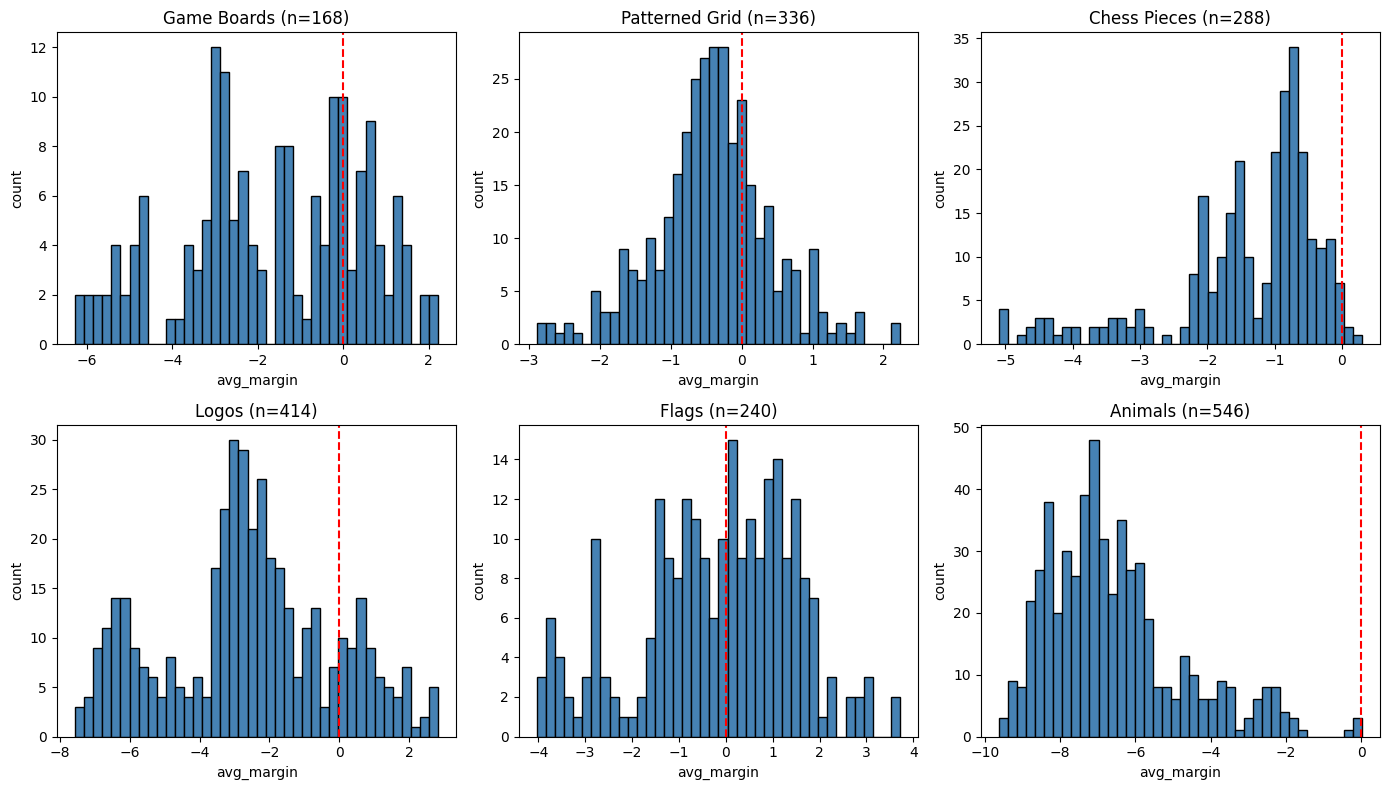

In [ ]:
# How extreme is the bias when it occurs?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
topics = df["topic"].unique()

for ax, topic in zip(axes.flat, topics):
    sub = df[df["topic"] == topic]
    ax.hist(sub["avg_margin"], bins=40, color="steelblue", edgecolor="black")
    ax.axvline(0, color="red", linestyle="--", label="zero")
    ax.set_title(f"{topic} (n={len(sub)})")
    ax.set_xlabel("avg_margin")
    ax.set_ylabel("count")

plt.tight_layout()
plt.savefig("avg_margin_by_topic.png", dpi=120)
plt.show()

In [ ]:
# Does Q1/Q2/Q3 split the bimodality?
print(df.groupby(["topic", "question_type"])["avg_margin"].agg(["mean", "count"]).round(3))

                               mean  count
topic          question_type              
Animals        Q1            -7.440    273
               Q2            -5.709    273
Chess Pieces   Q1            -1.587    144
               Q2            -1.226    144
Flags          Q1            -0.219    120
               Q2            -0.156    120
Game Boards    Q1            -2.220     84
               Q2            -1.113     84
Logos          Q1            -2.794    207
               Q2            -2.402    207
Patterned Grid Q1            -0.315    168
               Q2            -0.526    168


In [ ]:
# What columns do we have? Check for logo names or similar
print(df.columns.tolist())
print()
# If there's a 'subject' or 'item' column, group by it
sub_logos = df[df["topic"] == "Logos"]
print(sub_logos.head(3))

['topic', 'question_type', 'ground_truth', 'expected_bias', 'gold_seq_logprob', 'gold_avg_logprob', 'gold_entropy_step1', 'gold_entropy_mean', 'gold_n_tokens', 'bias_seq_logprob', 'bias_avg_logprob', 'bias_entropy_step1', 'bias_n_tokens', 'seq_margin', 'avg_margin', 'same_length', 'prefers_gold']

     topic question_type ground_truth expected_bias  gold_seq_logprob  \
792  Logos            Q1            2             1         -4.109375   
793  Logos            Q1            2             1         -3.574219   
794  Logos            Q1            2             1         -4.078125   

     gold_avg_logprob  gold_entropy_step1  gold_entropy_mean  gold_n_tokens  \
792         -4.109375            1.463867           1.463867              1   
793         -3.574219            1.377930           1.377930              1   
794         -4.078125            0.771484           0.771484              1   

     bias_seq_logprob  bias_avg_logprob  bias_entropy_step1  bias_n_tokens  \
792         -

In [ ]:
sub_logos = df[df["topic"] == "Logos"]
print("Logos: GT/bias pairs and avg_margin:")
print(sub_logos.groupby(["ground_truth", "expected_bias"])["avg_margin"]
      .agg(["mean", "count"]).round(2).sort_values("mean"))

sub_chess = df[df["topic"] == "Chess Pieces"]
print("\nChess: GT/bias pairs:")
print(sub_chess.groupby(["ground_truth", "expected_bias"])["avg_margin"]
      .agg(["mean", "count"]).round(2).sort_values("mean"))

Logos: GT/bias pairs and avg_margin:
                            mean  count
ground_truth expected_bias             
5            4             -6.10     90
4            3             -2.64    162
5            3             -1.89     90
2            1              1.00     72

Chess: GT/bias pairs:
                            mean  count
ground_truth expected_bias             
5            4             -1.99     84
17           16            -1.40      6
31           32            -1.30    144
3            2             -0.77     54


In [ ]:
df["relative_change"] = abs(df["ground_truth"].astype(float) - df["expected_bias"].astype(float)) / df["expected_bias"].astype(float)

from scipy.stats import pearsonr
r, p = pearsonr(df["relative_change"], df["avg_margin"])
print(f"Correlation between relative change size and avg_margin: r={r:.3f}, p={p:.2e}")

Correlation between relative change size and avg_margin: r=0.080, p=3.35e-04


In [ ]:
df["relative_change"] = (
    abs(df["ground_truth"].astype(float) - df["expected_bias"].astype(float))
    / df["expected_bias"].astype(float)
)

print("Correlation between relative_change and avg_margin, by topic:\n")
for topic in df["topic"].unique():
    sub = df[df["topic"] == topic]
    if sub["relative_change"].nunique() > 1:  # need variation to correlate
        r, p = pearsonr(sub["relative_change"], sub["avg_margin"])
        print(f"  {topic:15s}  r={r:+.3f}  p={p:.3e}  (n={len(sub)})")
    else:
        print(f"  {topic:15s}  no variation in relative_change")

Correlation between relative_change and avg_margin, by topic:

  Game Boards      r=-0.549  p=1.243e-14  (n=168)
  Patterned Grid   r=-0.329  p=6.661e-10  (n=336)
  Chess Pieces     r=+0.093  p=1.158e-01  (n=288)
  Logos            r=+0.807  p=2.869e-96  (n=414)
  Flags            r=+0.457  p=9.282e-14  (n=240)
  Animals          r=+0.670  p=1.959e-72  (n=546)


In [ ]:
# Look at the actual GT/bias pairs per topic to understand what relative_change captures
print("GT/bias pairs by topic with avg_margin and count:\n")
for topic in df["topic"].unique():
    sub = df[df["topic"] == topic]
    print(f"--- {topic} ---")
    print(sub.groupby(["ground_truth", "expected_bias"])["avg_margin"]
          .agg(["mean", "count"]).round(2))
    print()

GT/bias pairs by topic with avg_margin and count:

--- Game Boards ---
                            mean  count
ground_truth expected_bias             
10           9             -0.09     36
11           10            -1.32     12
18           19            -0.12     12
20           19             0.63     12
7            8             -5.25     24
8            9             -1.53     36
9            10            -1.11     12
             8             -3.01     24

--- Patterned Grid ---
                            mean  count
ground_truth expected_bias             
2            3             -0.91     54
3            4             -0.12    198
4            3             -1.03     18
5            4             -0.75     66

--- Chess Pieces ---
                            mean  count
ground_truth expected_bias             
17           16            -1.40      6
3            2             -0.77     54
31           32            -1.30    144
5            4             -1.99     84

--

In [ ]:
df["gt_minus_bias"] = df["ground_truth"].astype(float) - df["expected_bias"].astype(float)
df["direction"] = df["gt_minus_bias"].apply(lambda x: "added (GT>bias)" if x > 0 else "removed (GT<bias)")

print("Bias by direction of change:")
print(df.groupby("direction")["avg_margin"].agg(["mean", "count"]).round(3))

print("\nBy topic and direction:")
print(df.groupby(["topic", "direction"])["avg_margin"].agg(["mean", "count"]).round(3))

Bias by direction of change:
                    mean  count
direction                      
added (GT>bias)   -3.610   1392
removed (GT<bias) -0.852    600

By topic and direction:
                                   mean  count
topic          direction                      
Animals        added (GT>bias)   -6.574    546
Chess Pieces   added (GT>bias)   -1.509    144
               removed (GT<bias) -1.304    144
Flags          added (GT>bias)    0.071    120
               removed (GT<bias) -0.446    120
Game Boards    added (GT>bias)   -0.999     84
               removed (GT<bias) -2.334     84
Logos          added (GT>bias)   -2.598    414
Patterned Grid added (GT>bias)   -0.808     84
               removed (GT<bias) -0.292    252


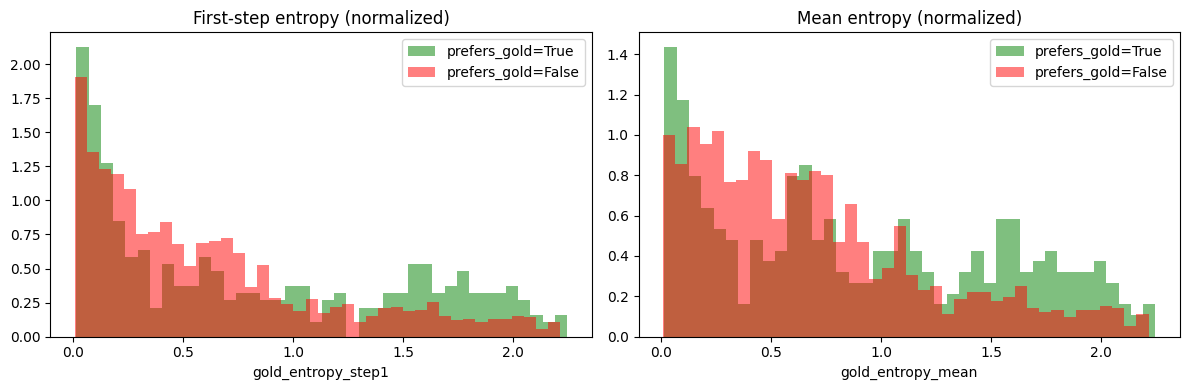

Mean entropy by gold token count and correctness:
gold_n_tokens  prefers_gold
1              False           0.674
               True            0.890
2              False           0.753
               True            0.929
Name: gold_entropy_mean, dtype: float64


In [ ]:
# Re-do but normalize histograms (density), and split by token length
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(True, "green"), (False, "red")]:
    sub = df[df["prefers_gold"] == label]["gold_entropy_step1"]
    ax[0].hist(sub, bins=40, alpha=0.5, label=f"prefers_gold={label}",
               color=color, density=True)
ax[0].set_xlabel("gold_entropy_step1")
ax[0].set_title("First-step entropy (normalized)")
ax[0].legend()

for label, color in [(True, "green"), (False, "red")]:
    sub = df[df["prefers_gold"] == label]["gold_entropy_mean"]
    ax[1].hist(sub, bins=40, alpha=0.5, label=f"prefers_gold={label}",
               color=color, density=True)
ax[1].set_xlabel("gold_entropy_mean")
ax[1].set_title("Mean entropy (normalized)")
ax[1].legend()

plt.tight_layout()
plt.show()

# Confirm token-length confound on entropy_mean
print("Mean entropy by gold token count and correctness:")
print(df.groupby(["gold_n_tokens", "prefers_gold"])["gold_entropy_mean"].mean().round(3))